<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Pro/AI_HW1_Regression_with_inference_pro_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (pro). Часть 1**

В этом домашнем задании (его первой части) вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;


> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$



**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns


random.seed(42)
np.random.seed(42)

### **Задание 0**
Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

`Your answer here`

Потому что 42 - это ответ на Главный вопрос жизни, Вселенной и всего остального

# **Часть 1 | EDA**


Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (1.7 балла)
- Визуализации признаков и их анализ (1.6 балл)

Всего можно набрать 3.3 основных балла и 0.25 бонусных.

В следующих частях, вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (1.7 балла)**

In [287]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(0.4 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)(0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла).

In [288]:
#1 
#df_train.info()
df_train.isna().sum()
# число - это количество пропусков

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          202
engine           202
max_power        196
torque           203
seats            202
dtype: int64

In [289]:
#2 
df_train.duplicated().sum()

985

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 104.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

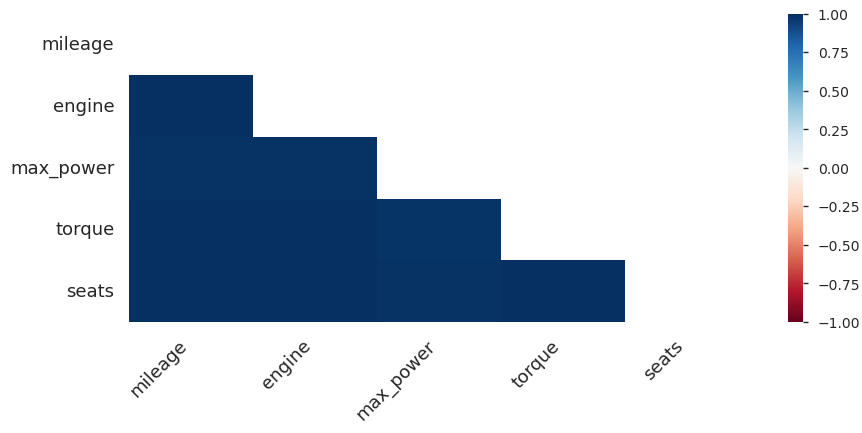

In [290]:
# 3
#!pip install ydata-profiling
from ydata_profiling import ProfileReport

ProfileReport(df_train, explorative=True).to_notebook_iframe()

#### 4 базовые выводы
Есть 11 предупреждений - немножечко пропущенных значений, корреляции между переменными и дубликаты
- перменная mileage содержит расход топлива, и его лучше перевести в числовую перемнную. Разные единицы измерения правильно перевести в одну какую-то. Пробелы можно заполнить средним значением, или взять значения такого же автомобиля (если есть такой же автомобиль) 
- max_power тоже лучеш перевести в числовой тип, вроде бы там только 1 единица измерения - bhp
- torque - какая-то сложная переменная, содержит сразу 2 значения - Mm@ и rpm. Надеюсь мне не придется превращать ее в нормальный признак
- Остальные переменные выглядят хорошо. есть немного выбросов, например очень дорогие машины, машины с очень большим пробегом или 14 сидячими местами. 

Есть очень сильные коррелиции между стоимостью, километражем и годом выпуска. 

In [293]:
for i in range(0, len(df_train)):
  try:
    ffil_value = float(df_train.loc[i, 'max_power'][:-4])
    df_train.loc[i, 'max_power'] = ffil_value

  except:
    if df_train.loc[i, 'max_power'] in [np.nan, 'nan']:
      continue
    elif df_train.loc[i, 'max_power'] == '0':
      ffil_value = float(df_train.loc[i, 'max_power'])
      df_train.loc[i, 'max_power'] = ffil_value
    else:
      df_train.loc[i, 'max_power'] = 0


In [294]:
df_train['max_power']

0         74.0
1       103.52
2         90.0
3         88.2
4        81.86
         ...  
6994     82.85
6995     110.0
6996      73.9
6997      70.0
6998      70.0
Name: max_power, Length: 6999, dtype: object

### **Задание 2 (0.2 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?
- [ ] Сделайте выводы по статистикам. Отсутсвие выводов равносильно по баллам невыполнению задания.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [295]:
# your code here
# 1 
df_train.describe()

,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [296]:
df_test.describe()

,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


#### Сравнение средних и медиан

В целом они совпдают у трейна и теста. 

Средняя стоимость автомобиля - 610 000 рупий (если это рупии), медианная - где-то 400 000 тысяч. Это типично, дорогие машины сильно влияют на среднее, но не на медиану. 

Аналогичная ситуация с пробегом - средний пробег почти на 10 тысяч выше медианного

In [297]:
df_train.describe(include='object')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803.0,6796
unique,1924,4,3,2,5,386,120,313.0,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74.0,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330.0,468


In [298]:
df_test.describe(include='object')

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


##### Выводы 

Самый популярный автомобиль - maruti. Это самый массовый автопроизводитель в Индии, так что скорее всего мы смотрим на индийский датасет. Данные, скорее всего, из 2020 года (максимальный год выпуска).

В основном автомобили на ручной коробке передач. 

Самый частый двигатель - 1248 CC, ставится в осном в малолитражки.

Можно сделать вывод, что большинство автомобилей в датасете - это бюджетные малолитражки на ручной корбке передач

### **Задание 3 (0.2 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.01 балла)
- [ ] Отобразите такие объекты (0.01 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.01 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.01 балла)
- [ ] Подумайте, могут ли в данных быть другие скрытые дубли? Предложите, как их можно отлавливать. (0.16 балла)

P.S тут данные без подвоха, но выводы нам нужны.

In [ ]:
# your code here
df_train = df_train.drop_duplicates()

In [301]:
# число дубликатов без учета цены
df_train.duplicated(subset=df_train.columns.drop('selling_price')).sum()

174

In [302]:
df_train = df_train.drop_duplicates(subset=df_train.columns.drop('selling_price'))

In [303]:
df_train = df_train.reset_index(drop=True)

#### Есть ли скрытые дубли и что с ними делать
- 2 одинаковых автомобиля могут иметь разные названия (из-за регистра или пробелов). Решение - внимательно посмотреть на все уникальные названия автомобилей. 
- По идее дубли могут быть на месте пропущенных значений, потому что в pandas None != None (вроде). Надо заполнить пропуски

In [304]:
df_train.shape

(5840, 13)

In [305]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.3 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [306]:
# your code here
# mileage
import re

def mileage_to_float(val):
    if pd.isna(val):
        return None
    
    match = re.search(r'\d+\.?\d*', str(val))
    if match:
        return float(match.group())
    return None


df_train['mileage'] = df_train['mileage'].apply(mileage_to_float)
df_test['mileage'] = df_test['mileage'].apply(mileage_to_float)

In [307]:
#engine 
# удаляем 'CC' и пробелы, переводим в int
df_train['engine'] = df_train['engine'].str.replace('CC', '', regex=False).str.strip().astype(float)
df_test['engine'] = df_test['engine'].str.replace('CC', '', regex=False).str.strip().astype(float)

In [308]:
# max_power

import re
import pandas as pd

def max_power_to_float(val):
    if pd.isna(val):
        return None
    match = re.search(r'\d+\.?\d*', str(val))
    if match:
        return float(match.group())
    return None

df_train['max_power'] = df_train['max_power'].apply(max_power_to_float)
df_test['max_power'] = df_test['max_power'].apply(max_power_to_float)


In [309]:
# torque, или как испортить 1.5 часа жизни на форматирование столбика
df_train['torque']
#очень некрасиво выглядит

0                  190Nm@ 2000rpm
1             250Nm@ 1500-2500rpm
2        22.4 kgm at 1750-2750rpm
3           11.5@ 4,500(kgm@ rpm)
4               113.75nm@ 4000rpm
                  ...            
5835              96.1Nm@ 3000rpm
5836                90Nm@ 3500rpm
5837             113.7Nm@ 4000rpm
5838    24@ 1,900-2,750(kgm@ rpm)
5839               190Nm@ 2000rpm
Name: torque, Length: 5840, dtype: object

Во всех строках torque есть либо 2, либо 3 числа - первое число это torque, второе (или второе и третье) - это max_torque. Поэтому сначала я извлеку из каждой строки числа, и потом обработаю их, в надежде что все получится

Чисел может быть от None (если пропуск) до 3:
- если пропуск - то сохранить None

Если не пропуск, то надо получить список из чисел
- Нашлось 0 чисел - это что-то странное
- Нашлось 1 число - это что-то странное
- Нашлось 2 числа - первое - это nm (или kgm), второе - rpm
- Нашлось 3 числа -  первое - это nm (или kgm), (второе - третье) - rpm (минимум и максимум)

Дальше надо найти единицы измерения (nm или kgm) и первести все kgm в nm

In [310]:
# функция для поиска всех чисел с точкой или запятой
def extract_numbers(val):
    if pd.isna(val):
        return None
    # ищем числа с точкой или запятой (поддерживаем оба разделителя)
    return re.findall(r'\d+(?:[.,]\d+)?', str(val))

# новый столбец содержит массив чисел. В идеале этих чисел должно быть 2
df_train['torque_numbers'] = df_train ['torque'].apply(extract_numbers)
df_test['torque_numbers'] = df_test ['torque'].apply(extract_numbers)

print('все уникальные значения количества чисел в переменной torque ',df_train [df_train['torque_numbers'].notna() ]  ['torque_numbers'].apply(len).unique())

print('все уникальные значения количества чисел в тесте в переменной torque ',df_test [df_test['torque_numbers'].notna() ]  ['torque_numbers'].apply(len).unique())



все уникальные значения количества чисел в переменной torque  [2 3 1]
все уникальные значения количества чисел в тесте в переменной torque  [3 2 1]


In [311]:
# небольшая проверка, чтобы не было чисел с запятыми
# Пройтись по всем спискам чисел и выбрать только с запятой
numbers_with_comma = df_train['torque_numbers'].explode()  # превращаем списки в отдельные строки
numbers_with_comma = numbers_with_comma[numbers_with_comma.str.contains(',', na=False)]
print(numbers_with_comma.unique())  # уникальные числа с запятой (их не должно быть)

numbers_with_comma = df_test['torque_numbers'].explode()  # превращаем списки в отдельные строки
numbers_with_comma = numbers_with_comma[numbers_with_comma.str.contains(',', na=False)]
print(numbers_with_comma.unique())  # уникальные числа с запятой (их не должно быть)




['4,500' '4,000' '3,500' '3,200' '1,900' '2,750' '2,500' '1,800' '3,000'
 '2,700' '2,000' '4,200' '4,100' '2,800' '3,750' '1,400' '3,800' '1,700'
 '2,200' '4,400' '3,400' '2,600' '4,800' '1,950' '4,700' '1,750' '4,600'
 '4,250' '1,600' '21,800' '1,500' '4,300']
['4,000' '4,100' '3,500' '2,700' '4,500' '2,500' '4,400' '1,900' '2,750'
 '3,000' '1,700' '2,200' '2,000' '2,680' '3,800' '4,700']


In [312]:
# Убираем запятые из всех чисел, типо 21,800 -> 21800 
df_train['torque_numbers'] = df_train['torque_numbers'].apply(
    lambda nums: None if not nums else [n.replace(',', '') for n in nums]
)
df_test['torque_numbers'] = df_test['torque_numbers'].apply(
    lambda nums: None if not nums else [n.replace(',', '') for n in nums]
)

In [313]:
# итак, есть список в котором 2 либо 3 значения (если 3 - то заменим второе и третье средним) либо 1 значение (чего не должно быть)
# посмотрим на все хначения где всего 1 число 

def has_single_number(x):
    return isinstance(x, list) and len(x) == 1

# train
mask = df_train['torque_numbers'].apply(has_single_number)
result = df_train[mask][['torque', 'torque_numbers']]
print(result)

# test
mask = df_test['torque_numbers'].apply(has_single_number)
result = df_test[mask][['torque', 'torque_numbers']]
print(result)


# видно что тут нет значения rpm, предположу что оно равно 4000)) 

     torque torque_numbers
129   400Nm          [400]
350   400Nm          [400]
5697  400Nm          [400]
    torque torque_numbers
148  400Nm          [400]
440  400Nm          [400]
865  400Nm          [400]
880  480Nm          [480]


In [315]:
# Функция для нормализации массива чисел
def normalize_torque_numbers(numbers):
    if not numbers:
        return None
    
    elif len(numbers) == 1:
        return [numbers[0], 4000.0] 
    elif len(numbers) == 2:
        # Преобразуем строки в числа с заменой запятой на точку
        nums = [float(x) for x in numbers]
        return nums
    elif len(numbers) == 3:
        # Берём первое число как есть, а второе и третье заменяем их средним
        first = float(numbers[0])
        second = float(numbers[1])
        third = float(numbers[2])
        avg = (second + third) / 2
        return [first, avg]

# Применяем нормализацию
df_train['torque_normalized'] = df_train['torque_numbers'].apply(normalize_torque_numbers)
df_test['torque_normalized'] = df_test['torque_numbers'].apply(normalize_torque_numbers)

In [316]:
# Ищем единицу измерения (kgm или nm), если ни то ни то - то nm 
df_train['torque_unit'] = df_train['torque'].str.extract(
    r'(kgm|nm)', flags=re.IGNORECASE, expand=False
)

# Приводим к нижнему регистру
df_train['torque_unit'] = df_train['torque_unit'].str.lower()

# Если torque не пустой, а torque_unit пустой → ставим 'nm'
df_train.loc[df_train['torque'].notna() & df_train['torque_unit'].isna(), 'torque_unit'] = 'nm'

# ---- то же самое для теста
df_test['torque_unit'] = df_test['torque'].str.extract(
    r'(kgm|nm)', flags=re.IGNORECASE, expand=False
)

# Приводим к нижнему регистру
df_test['torque_unit'] = df_test['torque_unit'].str.lower()

# Если torque не пустой, а torque_unit пустой → ставим 'nm'
df_test.loc[df_test['torque'].notna() & df_test['torque_unit'].isna(), 'torque_unit'] = 'nm'

In [317]:
# последнее - взять первое число из списка в torque_numbers, и есль torque_unit = kgm, то умножить его на 9.8. Это столбик torque. max_torque_rpm - просто второе число
def make_max_torque_rpm(nums):
    if not nums:
        return None
    else: return nums[1]

df_train['max_torque_rpm'] = df_train ['torque_normalized'].apply(make_max_torque_rpm)
df_test['max_torque_rpm'] = df_test ['torque_normalized'].apply(make_max_torque_rpm)

In [318]:
def make_torque(row):
    nums = row['torque_normalized']
    types = row['torque_unit']
    if not nums:  # обрабатывает None, [], и т.п.
        return None
    if types == 'kgm':
        return nums[0] * 9.8
    return nums[0]

df_train['torque1'] = df_train[['torque_normalized', 'torque_unit']].apply(make_torque, axis=1)
df_test['torque1'] = df_test[['torque_normalized', 'torque_unit']].apply(make_torque, axis=1)

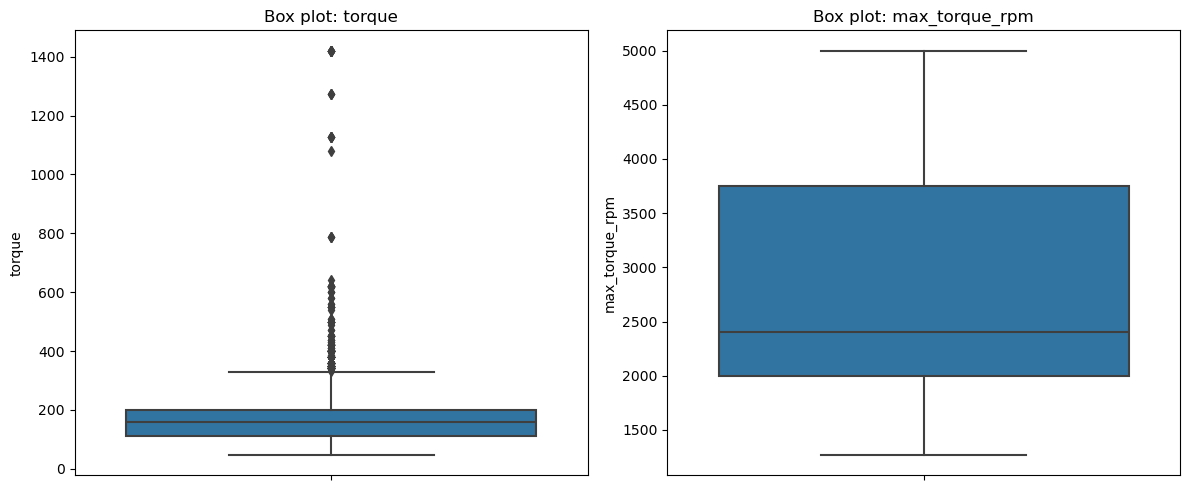

In [547]:
# box plot того что я наделал. Этот график немного нарушает таймлайн этого ноутбука и может у вас не построиться, простите


df_filtered = df_train
df_filtered = df_filtered[df_filtered['max_torque_rpm'] <= 20000]

# Построим два отдельных боксплота
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot для torque1 
sns.boxplot(data=df_filtered, y='torque', ax=axes[0])
axes[0].set_title('Box plot: torque')
axes[0].set_ylabel('torque')

# Boxplot для max_torque_rpm
sns.boxplot(data=df_filtered, y='max_torque_rpm', ax=axes[1])
axes[1].set_title('Box plot: max_torque_rpm')
axes[1].set_ylabel('max_torque_rpm')

plt.tight_layout()
plt.show()

Я удалил со второго графика одно странное значение max_torque большее 20 000, чтобы было красиво

Также в torque есть достаточно большие значения, скорее всего это дорогие машины с очень мощными двигателями

### **Задание 5 (0.3 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [ ]:
# я поудалял из обработанного датасета кучу лишних столбиков (утратив код который это делал), и сохранил новый красивый датасет. 

# df_train.to_csv('df_train.csv', index=False)
# df_test.to_csv('df_test.csv', index=False)

In [95]:
import pandas as pd
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

Почему надо считать медиану а не среднее? 

Вроде бы выше было видно что среднее значение немного завышено из-за больших значений. Медиана более устойчива к выбросам в таких скошенных вправо распределениях

Как правильно считать медиану для теста? По тренировочным данным и в трейне и в тесте, чтобы никак не использовать информацию о неизвестном распределении теста

In [96]:
print(df_train.isna().sum())

mileage = df_train['mileage'].median()
engine = df_train['engine'].median()
max_power = df_train['max_power'].median()
seats = df_train['seats'].median()
max_torq = df_train['max_torque_rpm'].median()
torque = df_train['torque'].median()
# случайно вызвал код уже после заполнения пропусков

name                0
year                0
selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
mileage           186
engine            186
max_power         183
seats             186
max_torque_rpm    187
torque            187
dtype: int64


In [97]:
# Выводим медианы
print("Медианы:")
print(f"mileage:         {mileage}")
print(f"engine:          {engine}")
print(f"max_power:       {max_power}")
print(f"seats:           {seats}")
print(f"max_torque_rpm:  {max_torq}")
print(f"torque:          {torque}")

Медианы:
mileage:         19.369999999999997
engine:          1248.0
max_power:       81.86
seats:           5.0
max_torque_rpm:  2400.0
torque:          160.0


In [98]:
# пропуски в трейне
df_train['mileage'] = df_train['mileage'].fillna(mileage)
df_train['engine'] = df_train['engine'].fillna(engine)
df_train['max_power'] = df_train['max_power'].fillna(max_power)
df_train['seats'] = df_train['seats'].fillna(seats)
df_train['max_torque_rpm'] = df_train['max_torque_rpm'].fillna(max_torq)
df_train['torque'] = df_train['torque'].fillna(torque)

# пропуски в тесте 
df_test['mileage'] = df_test['mileage'].fillna(mileage)
df_test['engine'] = df_test['engine'].fillna(engine)
df_test['max_power'] = df_test['max_power'].fillna(max_power)
df_test['seats'] = df_test['seats'].fillna(seats)
df_test['max_torque_rpm'] = df_test['max_torque_rpm'].fillna(max_torq)
df_test['torque'] = df_test['torque'].fillna(torque)

### **Задание 6 (0.2 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [99]:
# your code here
df_train['seats'] = df_train['seats'].astype('Int64')
df_train['engine'] = df_train['engine'].astype('Int64')

df_test['seats'] = df_test['seats'].astype('Int64')
df_test['engine'] = df_test['engine'].astype('Int64')

`Your answer here`

Потому что количество сидячих мест описыват тип автомобиля - есть маленькие мини-машинки на 2 места, а есть мест на 15, и это уже скорее маршрутка или даже целый автобус

### **Задание 7 (0.1 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [100]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,max_torque_rpm,torque
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.0,5840.000000,5840.0,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.892354,5.426712,2846.975146,175.347077
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.661223,0.982344,973.649268,107.112266
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.0,0.000000,2.0,1269.350000,47.040000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.0,68.000000,5.0,2000.000000,111.800000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.0,81.860000,5.0,2400.000000,160.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.0,99.000000,5.0,3750.000000,200.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.0,400.000000,14.0,21800.000000,1862.000000


`Your answer here`

Заполнение пропусков действительно меняет распределение. На графике расспредления появляется лишний пик в точке медианы, из-за чего поменьше станет дисперсия, чуть чуть уменьшится среднее. (или даже не чуть-чуть)

## **Визуализации и корреляция (1.6 балла + 0.25)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

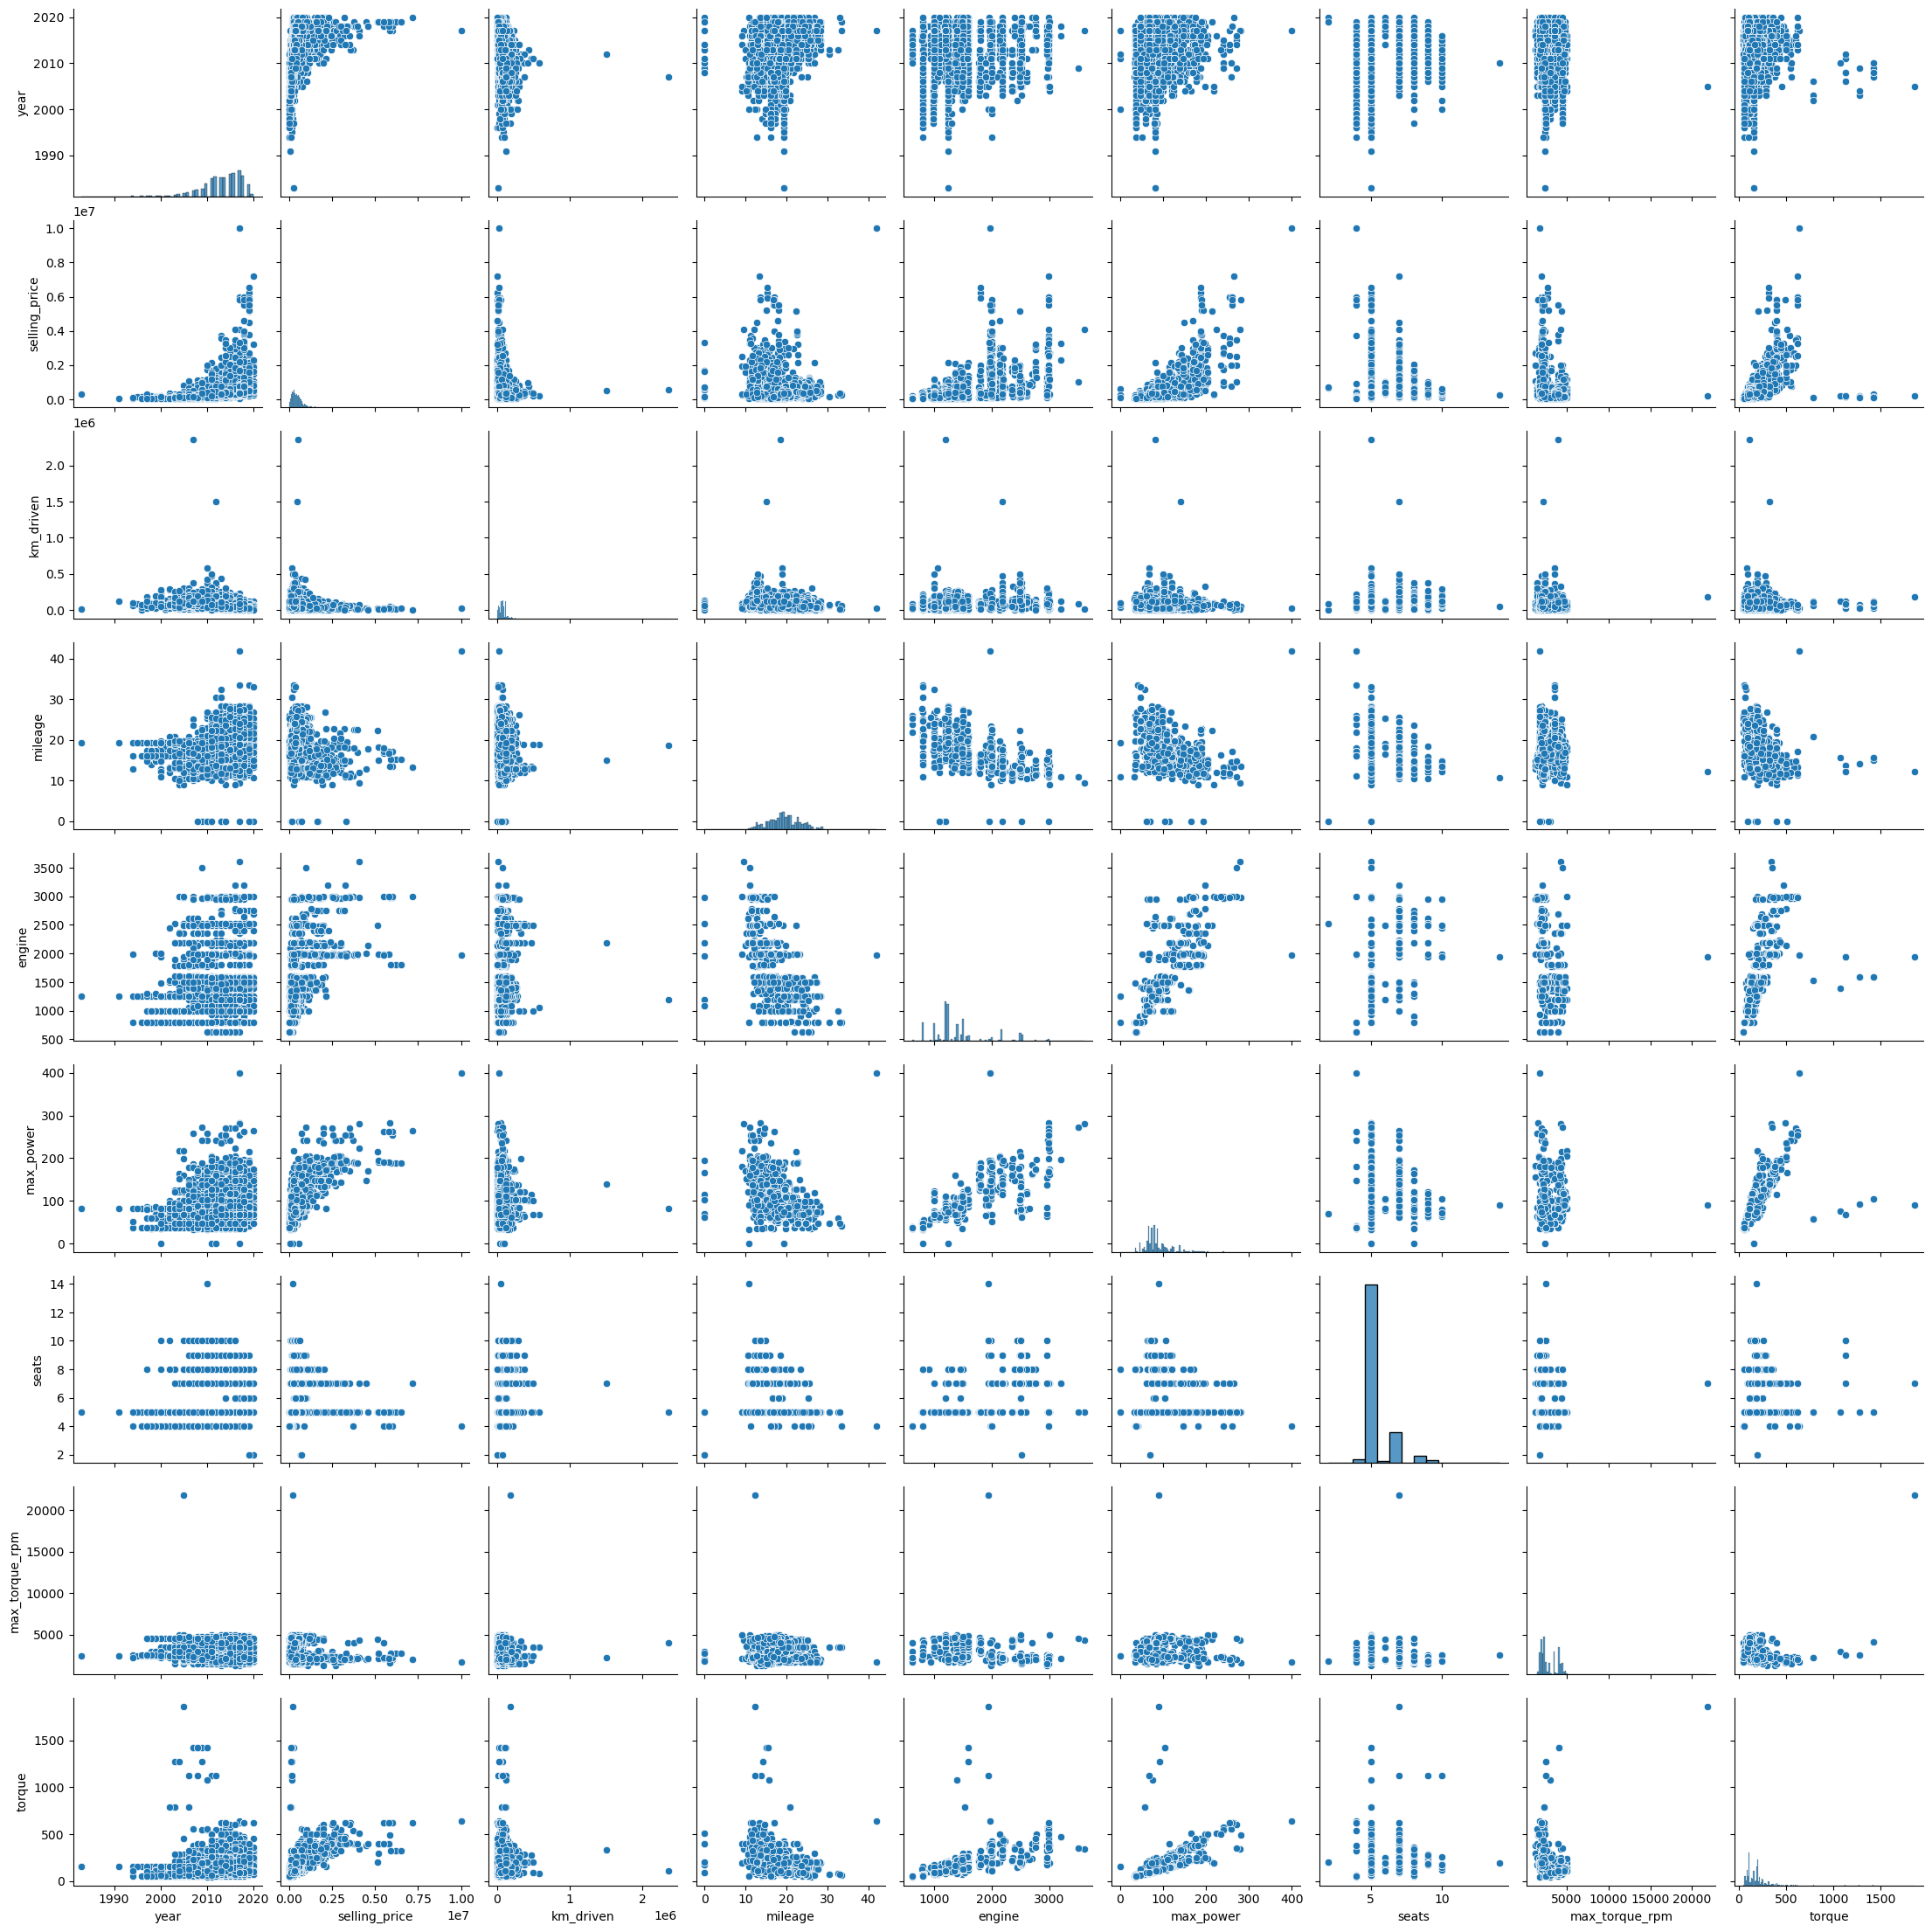

In [101]:
# your code here
# шаг 1
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_train.select_dtypes(include='number'))
plt.show()


Можно предположить, что есть зависимость целевой переменной с year, engine, max_power, torque

Можно предположить, что коррелирующие переменные - max_power, engine и torque. 

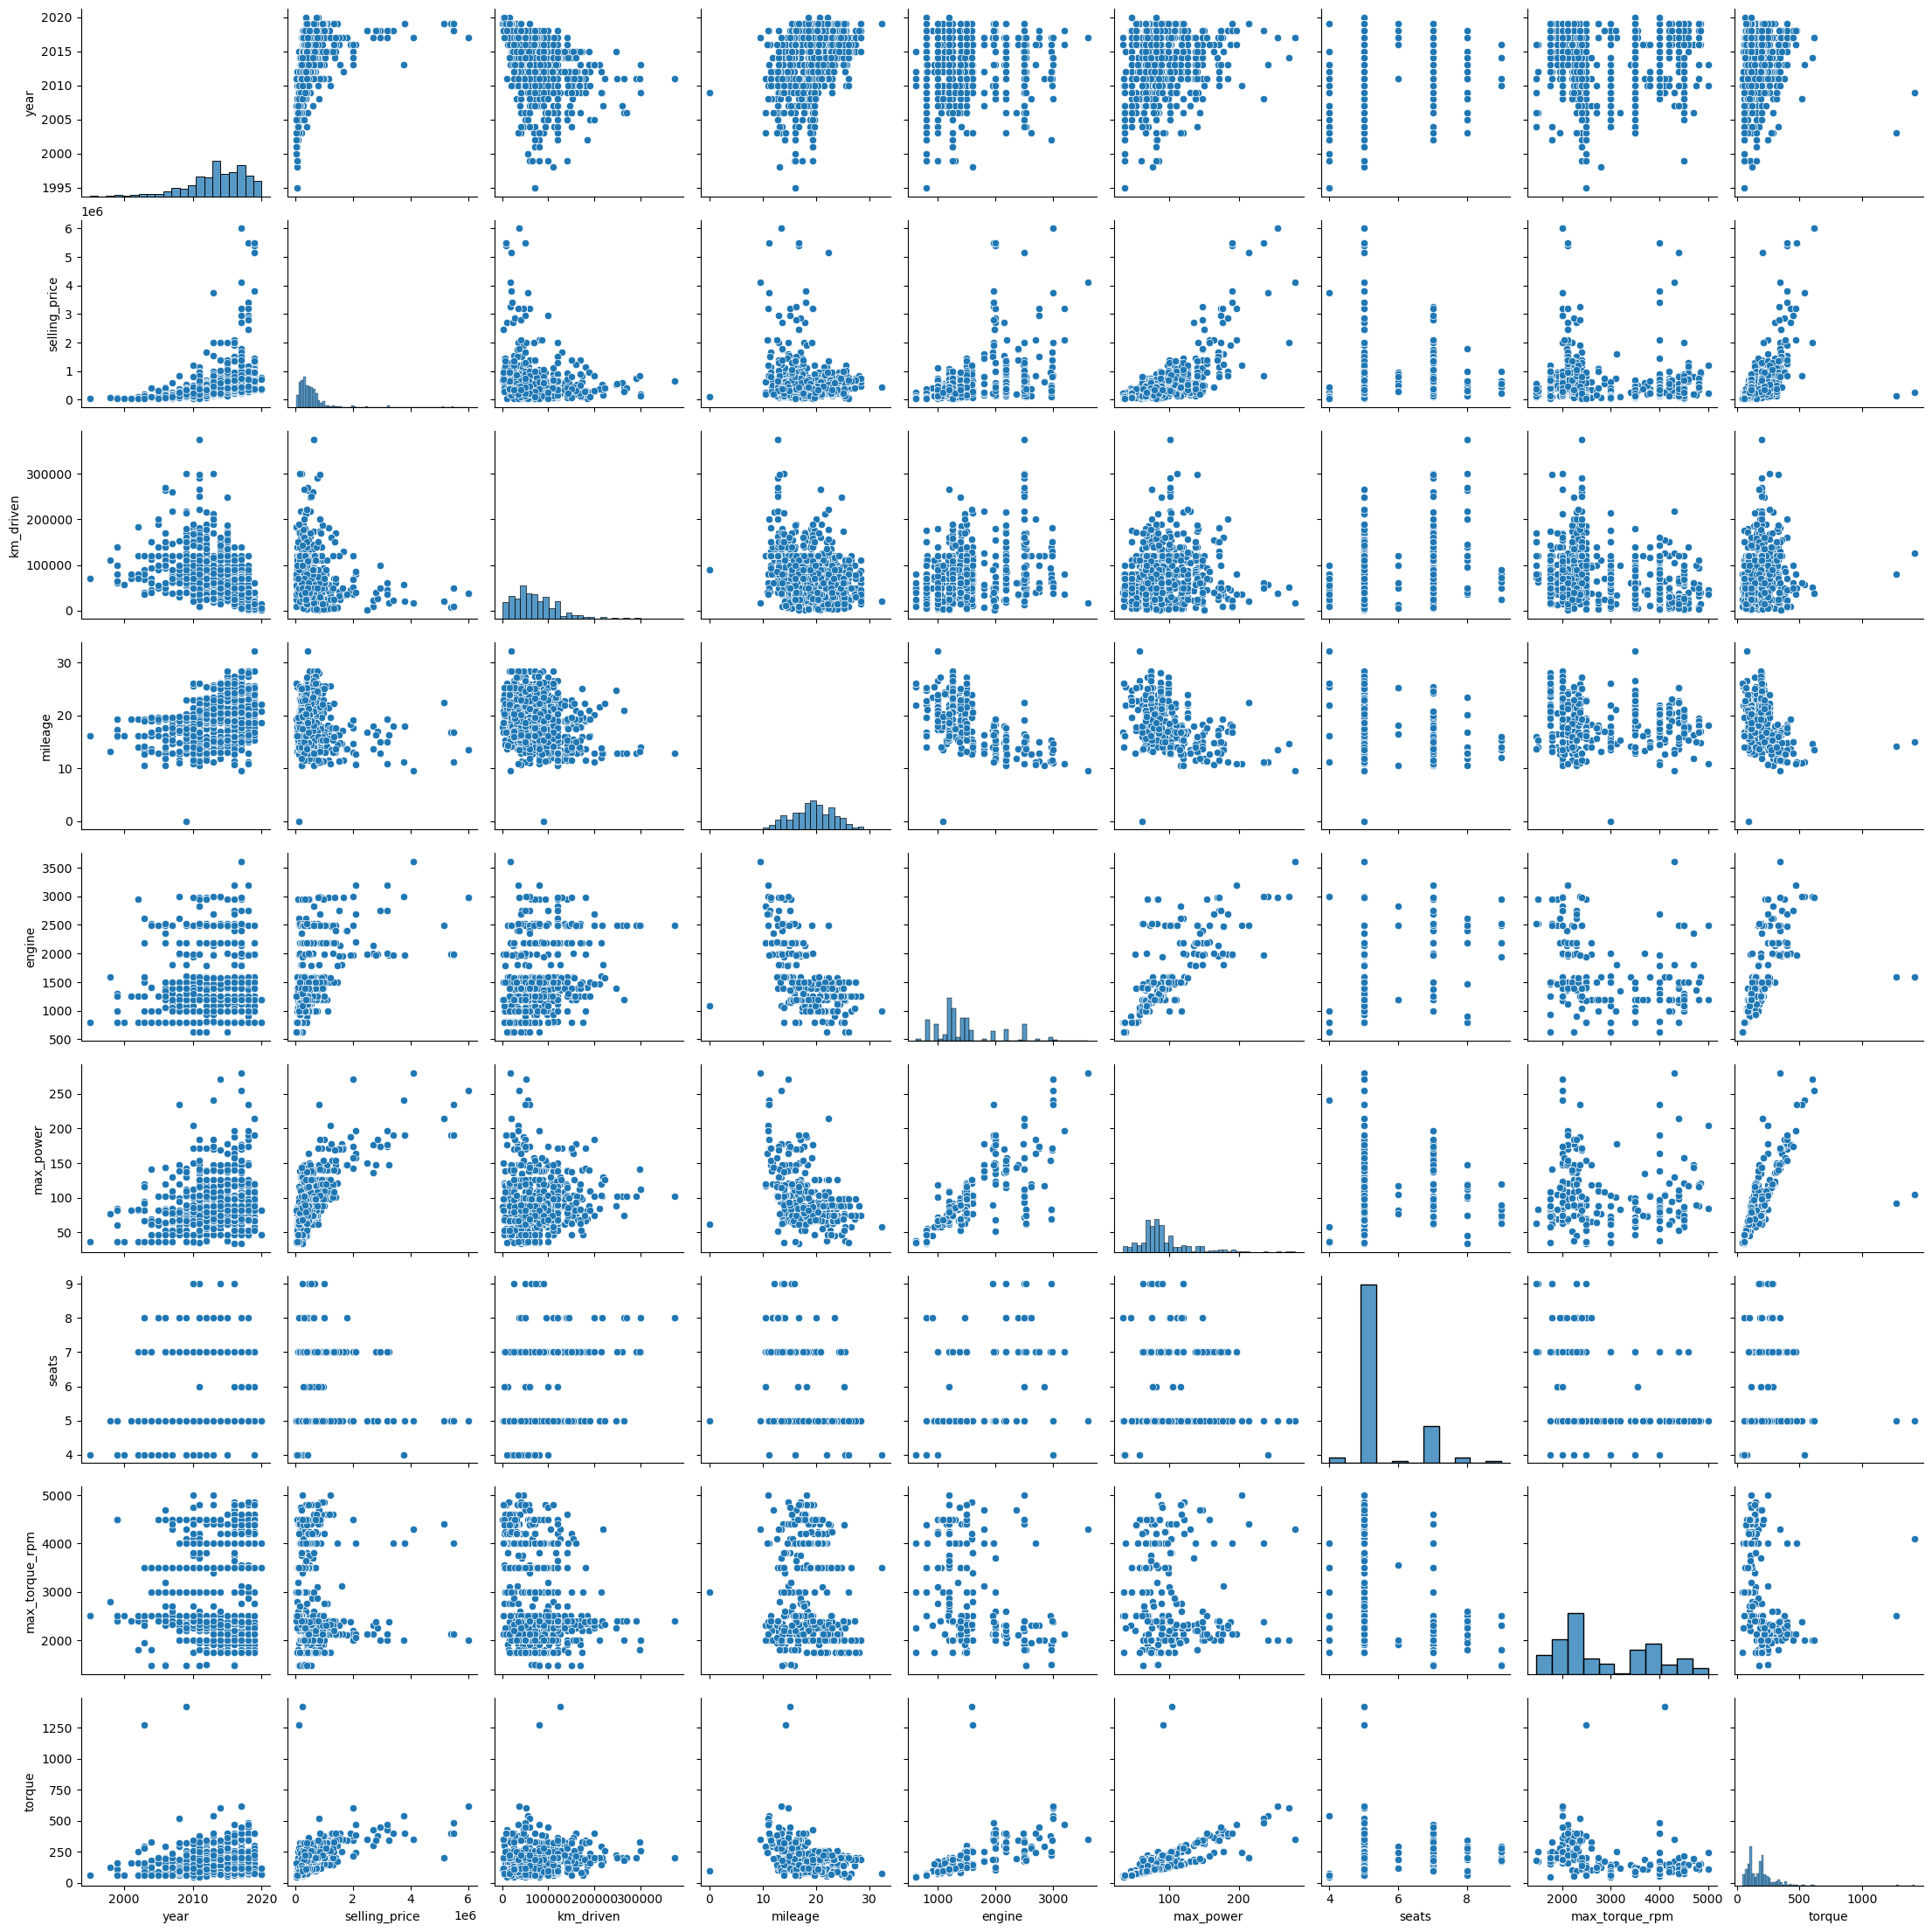

In [102]:

sns.pairplot(df_test.select_dtypes(include='number'))
plt.show()


### **Задание 9 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

                    year  selling_price  km_driven   mileage    engine  \
year            1.000000       0.427279  -0.368966  0.341334  0.002819   
selling_price   0.427279       1.000000  -0.164828 -0.104769  0.447672   
km_driven      -0.368966      -0.164828   1.000000 -0.182086  0.229766   
mileage         0.341334      -0.104769  -0.182086  1.000000 -0.572893   
engine          0.002819       0.447672   0.229766 -0.572893  1.000000   
max_power       0.158207       0.692725   0.024379 -0.372197  0.681247   
seats           0.041178       0.149953   0.192328 -0.451059  0.652172   
max_torque_rpm  0.034410      -0.169809  -0.231658 -0.095098 -0.380303   
torque          0.053285       0.466650   0.112932 -0.237595  0.600193   

                max_power     seats  max_torque_rpm    torque  
year             0.158207  0.041178        0.034410  0.053285  
selling_price    0.692725  0.149953       -0.169809  0.466650  
km_driven        0.024379  0.192328       -0.231658  0.112932  
mil

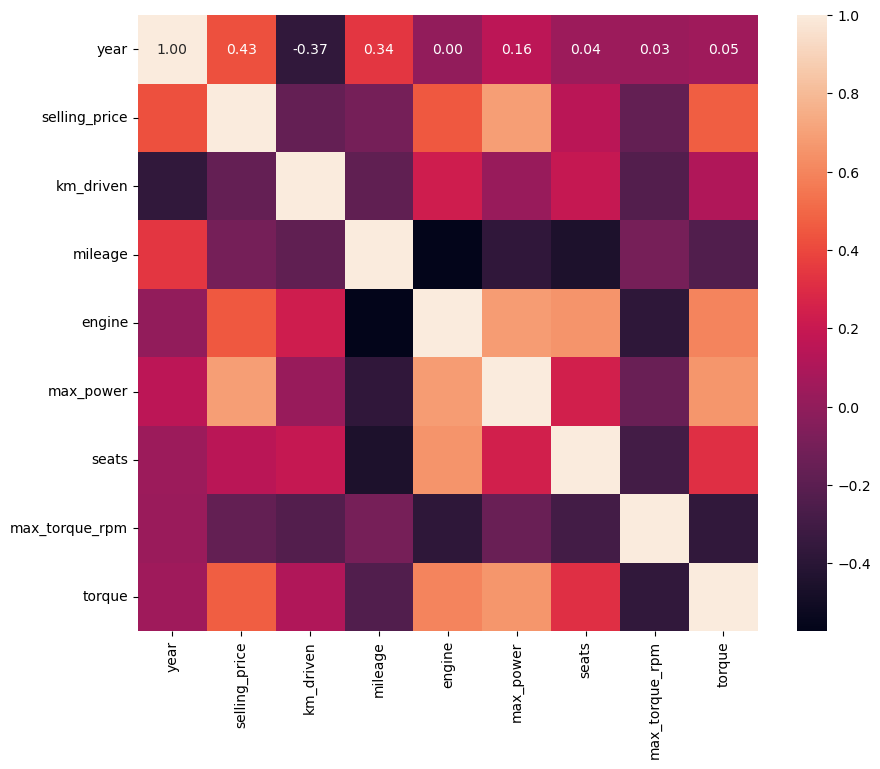

In [103]:
# your code here
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train.select_dtypes(include='number').corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?
 - Изучите типы корреляций в `pd.corr()`. Какую вы использовали по умолчанию?

`Your answer here`
- Наименьшая коррелция между годом и двигателем - 0.00281899537820299
- Сильные коррелиции: max_power - selling price, engine-seats, engine-torque, max_power-torque, 
- чем меньше год, тем больше километров проехала машина, потому что корреляция между ними отрицательная (-0.3).
- По умолчанию считается pearson, еще есть spearman и kendall. 

### **Задание 10 (0.6 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче, попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ] Сделайте выводы


Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [104]:
# искусственный пример для отладки кода 
sample = pd.DataFrame({
    "A": [10, 20, 10],   # повторы
    "B": [3, 1, 2],      # все разные
    "C": [7, 7, 9],      # повторы
    "D": [100, 50, 150]  # все разные
})



def spearman(df):
    # считает корреляцию спирмана как корреляция Пирсона от рангов 
    # 

    # перевести в чистый нумпай чтобы не использвоать ничего лишнего
    X = np.asarray(df).T

    # ТЕперь надо превратить этот Х в массив рангов
    order = np.argsort(X) # например [1 2 1 3] -> [0 2 1 3]
    ranks = np.empty_like(X, dtype=float) # заранее выделить память для рангов

    # если в массиве есть повторы, то их надо заменить средним значением. Например:
    # [10 10 20 40] -> [1.5 1.5 3 4], то есть 1 и 2 заменились на их среднее
    for ind, ar in enumerate(X):
        i = 0
        while i< len(ar):
            # внутри этого цикла находим начало и конец промежутков с одинаковыми значениями
            # и сразу считаем средний ранг 
            j = i
            while j+1 < len(ar) and ar[order[ind][i]] == ar[order[ind][j+1]]:
                j+=1
            
            avg = (i+j) /2 +1
            ranks[ind][order[ind][i:j+1]] = avg

            i = j+1

    # Посчитаем корреляцию как корреляция Пирсона, но на рангах (вроде бы это так работает)
    def formula_pearson(x, y): 
        # вход - 2 признака (одинакоая длина, np arrays), ранги
        # выход - значение корреляции Спирамана
        # return np.corrcoef(x, y)[0, 1]

        if x.shape[0] != y.shape[0]:
            raise ValueError("x и y должны иметь одинаковую длину")

        # центрируем и считаем числитель формулы
        x_c = x - np.mean(x)
        y_c = y - np.mean(y)
        numerator = np.dot(x_c, y_c)

        # знаменатель - корень произведения суммы квадратов отклонения
        x_sd = np.dot(x_c, x_c)
        y_sd = np.dot(y_c, y_c)

        denominator = np.sqrt(x_sd * y_sd)
        if denominator == 0: return np.nan
        return numerator / denominator
        
    n_feat = ranks.shape[0]
    corrs = np.empty((n_feat, n_feat), float)

    for i in range(n_feat):
        for j in range(n_feat):
            corrs[i, j] = formula_pearson(ranks[i], ranks[j])

    # итак я все посчитал в НУМПАЕ, тепперь для удобства верну красивый df 
    colnames = list(df.columns)
    corrs_df = pd.DataFrame(corrs, index=colnames, columns=colnames)


    return corrs_df

spearman(sample)



,A,B,C,D
A,1.000000,-0.866025,-0.500000,-0.866025
B,-0.866025,1.000000,0.000000,0.500000
C,-0.500000,0.000000,1.000000,0.866025
D,-0.866025,0.500000,0.866025,1.000000


In [105]:
spearman(df_train.select_dtypes(include='number'))



,year,selling_price,km_driven,mileage,engine,max_power,seats,max_torque_rpm,torque
year,1.000000,0.707123,-0.569659,0.346132,-0.038056,0.166267,0.048291,0.004759,0.107402
selling_price,0.707123,1.000000,-0.295665,0.026186,0.463577,0.612600,0.317605,-0.252928,0.583054
km_driven,-0.569659,-0.295665,1.000000,-0.198466,0.304504,0.040655,0.195317,-0.309509,0.238927
mileage,0.346132,0.026186,-0.198466,1.000000,-0.429871,-0.308239,-0.435458,-0.157404,-0.155412
engine,-0.038056,0.463577,0.304504,-0.429871,1.000000,0.713435,0.527716,-0.468544,0.839067
max_power,0.166267,0.612600,0.040655,-0.308239,0.713435,1.000000,0.304095,-0.148510,0.778148
seats,0.048291,0.317605,0.195317,-0.435458,0.527716,0.304095,1.000000,-0.309193,0.433025
max_torque_rpm,0.004759,-0.252928,-0.309509,-0.157404,-0.468544,-0.148510,-0.309193,1.000000,-0.652000
torque,0.107402,0.583054,0.238927,-0.155412,0.839067,0.778148,0.433025,-0.652000,1.000000


In [106]:
df_train.select_dtypes(include='number').corr(method='spearman')

,year,selling_price,km_driven,mileage,engine,max_power,seats,max_torque_rpm,torque
year,1.000000,0.707123,-0.569659,0.346132,-0.038056,0.166267,0.048291,0.004759,0.107402
selling_price,0.707123,1.000000,-0.295665,0.026186,0.463577,0.612600,0.317605,-0.252928,0.583054
km_driven,-0.569659,-0.295665,1.000000,-0.198466,0.304504,0.040655,0.195317,-0.309509,0.238927
mileage,0.346132,0.026186,-0.198466,1.000000,-0.429871,-0.308239,-0.435458,-0.157404,-0.155412
engine,-0.038056,0.463577,0.304504,-0.429871,1.000000,0.713435,0.527716,-0.468544,0.839067
max_power,0.166267,0.612600,0.040655,-0.308239,0.713435,1.000000,0.304095,-0.148510,0.778148
seats,0.048291,0.317605,0.195317,-0.435458,0.527716,0.304095,1.000000,-0.309193,0.433025
max_torque_rpm,0.004759,-0.252928,-0.309509,-0.157404,-0.468544,-0.148510,-0.309193,1.000000,-0.652000
torque,0.107402,0.583054,0.238927,-0.155412,0.839067,0.778148,0.433025,-0.652000,1.000000


#### Выводы 

1) У меня получилось шок 
2) Видна более сильная корреляция между ценой и годом продажи - она стала аж 0.7
3) Цена все еще коррелирует с max_power
4) max_power  torque и engine сильно коррелируют все еще. 

interval columns not set, guessing: ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'max_torque_rpm', 'torque']


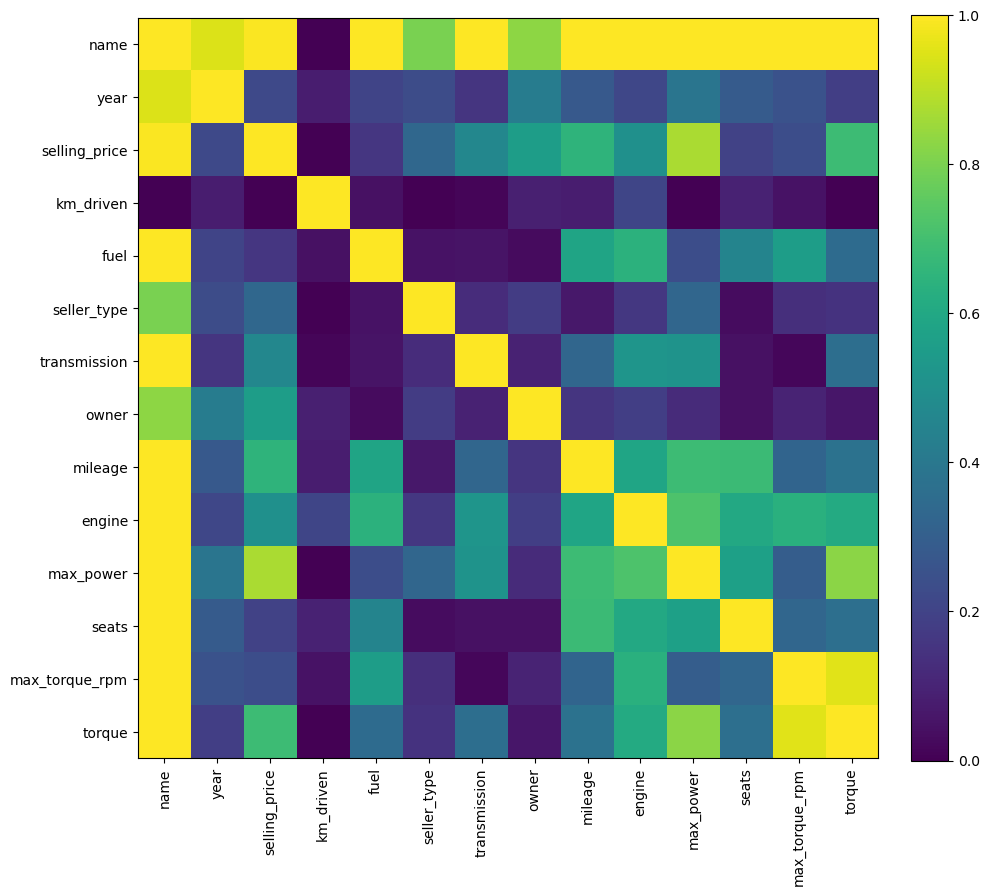

In [107]:
from phik import phik_matrix


phik_corr = df_train.phik_matrix()


labels = phik_corr.columns
mat = phik_corr.values
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(mat, vmin=0, vmax=1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)


fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Name коррелирует пчти со всем датасетом, кроме selling type и owner (с ними тоже, но не так сильно) и пробегом (с ним вообще не коррелирует). Думаю что это из-за того, что автомобиль однйо и той же марки имеет плюс минус одианквые характеристики. 

### **Дополнительные визуализации (бонус 0.25 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.
Один график: 0.125 балла, при условии, что он обоснован.

In [ ]:
# your code here

# **Часть 2 (1.7 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.05 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [108]:
y_train = df_train['selling_price'] # your code here
X_train = df_train.select_dtypes(include = 'number') # your code here
X_train = X_train.drop(columns = ['selling_price'])
X_train.columns

Index(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'max_torque_rpm', 'torque'],
      dtype='object')

In [109]:
assert X_train.shape == (5840, 8)

In [110]:
y_test = df_test['selling_price']
X_test = df_test.select_dtypes(include = 'number') 
X_test = X_test.drop(columns = ['selling_price'])

In [111]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [112]:
import math
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

base_model = LinearRegression()
base_model.fit(X_train, y_train)
base_model.feature_names_ = X_train.columns.tolist()


y_pred_train = base_model.predict(X_train)
y_pred_test = base_model.predict(X_test)

# Метрики для train
r2_train = r2_score(y_train, y_pred_train)
mse_train = MSE(y_train, y_pred_train)

# Метрики для test
r2_test = r2_score(y_test, y_pred_test)
mse_test = MSE(y_test, y_pred_test)



print("TRAIN METRICS:")
print("R² train:", r2_train)
print("MSE train:", mse_train)
print('RMSE', math.sqrt(mse_train))

print("\nTEST METRICS:")
print("R² test:", r2_test)
print("MSE test:", mse_test)
print('RMSE', math.sqrt(mse_test))


TRAIN METRICS:
R² train: 0.6000904696530618
MSE train: 114629403272.12918
RMSE 338569.6431638979

TEST METRICS:
R² test: 0.596144382949634
MSE test: 232147741035.53464
RMSE 481817.12405801297


Выводы 

Модель очень плохоая)

РАзмер ошибки RMSE примерно равен медианной стоимости автомобиля, что никуда не годится 

R^2 метрика - примерно 0.6 говорит о том, что модель объяснила примерно 60% вариации стоимости относительно срденего, чего наверно мало для такой задачи

### **Задание 13 (0.15 балла)**

- [ ] Реализуйте  руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [113]:
import numpy as np
def coef_deter(y, y_pred):
    # пусть y_pred, y - массивы нумпай
    ss_res = np.sum((y-y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2) 

    return 1 - (ss_res / ss_tot)

coef_deter(y_train, y_pred_train)

0.6000904696530618

`Your answer here`

Коэффициент детерминации $R^2$ - это обобщение MSE, которая решает проблему неограниченности метрики 
- Числитель (ss_res) - просто mse
- Знаменатель (ss_tot) - дисперсия таргета. Она не зависит от модели, это размер ошибки константного предсказания
В лучшем случае, при нулевом mse, значение метрики равно 1. При росте ошибки модели будет расти дробь, которая отнимается из единицы, то есть значение метрики будет падать. Если ошибка модели станет больше константного предсказания, занчение метрики станет отрицательной. По идее в такой моделе смысла никакого нет, поэтому можно предполагать значение 0 (ошибка модели == ошибка константного предсказания) как худший случай

### **Бонус (0.15 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [114]:
# your code here
def adj_coef_deter(y, y_pred, n_features):
    r_2 = coef_deter(y, y_pred)
    return 1 - (1- r_2)*(len(y)-1)/(len(y)-n_features-1)

adj_coef_deter(y_train, y_pred_train, 7)


0.5996104685020966

`Your answer here`

Обычный $R^2$ растет при добавления нового признака. Даже если он никак не обхясняет целевую переменную, линейная регрессия подберет такой вес, чтобы этот признак немного уменьшил ошибку. Adjusted $R^2$ штрафует модель за каждый новый признак, поэтому значение метрики станет больше только если признак оказался полезным. 

### **Задание 14 (0.05 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [115]:
# your code here
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # только применить без обучения

# вернуть DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

scaled_model.feature_names_ = X_train_scaled.columns.tolist()  # для сохранения в пикл



y_pred_train = scaled_model.predict(X_train_scaled)
y_pred_test = scaled_model.predict(X_test_scaled)

# Метрики для train
r2_train = r2_score(y_train, y_pred_train)
mse_train = MSE(y_train, y_pred_train)

# Метрики для test
r2_test = r2_score(y_test, y_pred_test)
mse_test = MSE(y_test, y_pred_test)


print("TRAIN METRICS:")
print("R² train:", r2_train)
print("MSE train:", mse_train)
print('RMSE', math.sqrt(mse_train))

print("\nTEST METRICS:")
print("R² test:", r2_test)
print("MSE test:", mse_test)
print('RMSE', math.sqrt(mse_test))

TRAIN METRICS:
R² train: 0.6000904696530602
MSE train: 114629403272.12961
RMSE 338569.64316389855

TEST METRICS:
R² test: 0.5961443829496358
MSE test: 232147741035.53357
RMSE 481817.12405801186


Вывод - стандартизация не улучшила модель, видимо потому что без регуляризации стандартизация никак не изменила оптимальное решение

### **Задание 15 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [116]:
# your code here
print(X_train.columns)
scaled_model.coef_

Index(['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'max_torque_rpm', 'torque'],
      dtype='object')


array([165001.89051609, -49739.00751368,  -8791.93184894,  17248.50357722,
       324119.84122123, -31175.8317698 , -60312.6801252 ,   8238.25842323])

Cамый значимый признак - max_power и год выпуска. Наименьшие значения у mileage и torque

### **Задание 16 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [118]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)
lasso_model.feature_names_ = X_train_scaled.columns.tolist()  # для сохранения в пикл




y_pred_train = lasso_model.predict(X_train_scaled)
y_pred_test = lasso_model.predict(X_test_scaled)

# Метрики для train
r2_train = r2_score(y_train, y_pred_train)
mse_train = MSE(y_train, y_pred_train)

# Метрики для test
r2_test = r2_score(y_test, y_pred_test)
mse_test = MSE(y_test, y_pred_test)



print("TRAIN METRICS:")
print("R² train:", r2_train)
print("MSE train:", mse_train)
print('RMSE', math.sqrt(mse_train))

print("\nTEST METRICS:")
print("R² test:", r2_test)
print("MSE test:", mse_test)
print('RMSE', math.sqrt(mse_test))


TRAIN METRICS:
R² train: 0.6000904696111862
MSE train: 114629403284.13232
RMSE 338569.6431816242

TEST METRICS:
R² test: 0.5961432485162457
MSE test: 232148393140.24072
RMSE 481817.8007714542


In [119]:
lasso_model.coef_


array([164999.81945197, -49738.10577047,  -8788.58534873,  17247.53101517,
       324120.97577958, -31172.19803902, -60310.45723268,   8237.55852025])

Ни один из признаков не занулился и качество не выросло. Надо усилить коэффициент регуляризации альфа, тогда ожидаю что занулится что-то не очень значимое (например, torque) и качество подрастет

### **Задание 17. Финальный рывок (0.4 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

   param_alpha  mean_train_score  mean_test_score
0        0.001          0.600908         0.573960
1         0.01          0.600908         0.573960
2          0.1          0.600908         0.573961
3            1          0.600908         0.573961
4           10          0.600908         0.573968
5          100          0.600908         0.574030
6          500          0.600896         0.574290
7         1000          0.600860         0.574582
8         5000          0.600032         0.577265
9        10000          0.598282         0.580109
10       20000          0.594137         0.582909
11       30000          0.587867         0.581878
12       40000          0.579151         0.576833
13       50000          0.569012         0.569135


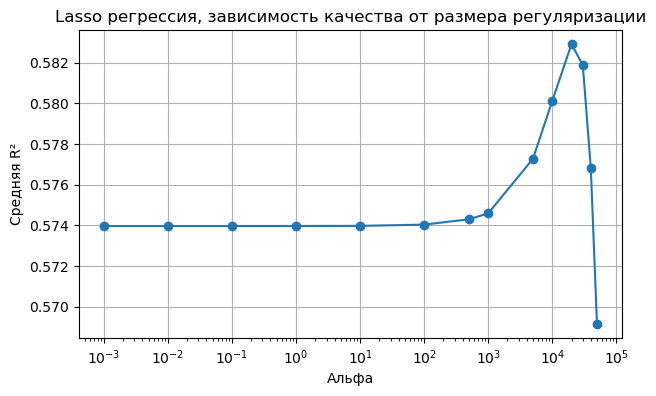

Лучший альфа: 20000
Лучшее R²: 0.5829091156824929
Коэффициенты: [147930.31264487 -29601.29448864      0.              0.
 323015.78870202     -0.         -34795.17423996      0.        ]


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# модель
lasso = Lasso(max_iter=30000)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 5000, 10000, 20000, 30000, 40000, 50000]
}

grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    return_train_score=True
)

grid_search_lasso.fit(X_train_scaled, y_train)


results = pd.DataFrame(grid_search_lasso.cv_results_)
table = results[['param_alpha', 'mean_train_score', 'mean_test_score']]
print(table)

# график запвисимости метрики от размера альфа
plt.figure(figsize=(7,4))
plt.plot(results['param_alpha'], results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('Альфа')
plt.ylabel('Средняя R²')
plt.title('Lasso регрессия, зависимость качества от размера регуляризации')
plt.grid(True)
plt.show()

# ЛУчшая модель
print("Лучший альфа:", grid_search_lasso.best_params_['alpha'])
print("Лучшее R²:", grid_search_lasso.best_score_)
print("Коэффициенты:", grid_search_lasso.best_estimator_.coef_)



In [121]:
lasso_best = grid_search_lasso.best_estimator_
lasso_best.feature_names_ = X_train_scaled.columns.tolist()

- Для каждого фолда кросс-валидации надо обучить по len(param_grid) значений. Всего - 10x15=150
- Параметры в param_grid - Я перебрал только разные коэффициенты регуляризации L1 - alpha. Большая альфа сильнее штрафует за веса, и модели в какой-то момент станет выгодно занулить некоторые веса.
- При небольших значениях альфа (где-то до 10000) модель не зануляла признаки, то есть регуляризации как таковой не было, и модель переобучалась. При значении альфа где-то 20 000 модель занулила аж 4 признака, и переобучения не было (ошибка трейна примерно равна ошибке теста). При последующем увеличении альфа модель уже наачла занулять полезные признаки, и качество начало падать

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

Отвыеты на вопросы 
- число моделей - (10 (alpha) × 6 (l1_ratio) × 10 (cv)) = 600 моделей

In [124]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000, 10000],
    'l1_ratio': [0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100,
                                   500, 1000, 10000],
                         'l1_ratio': [0.05, 0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

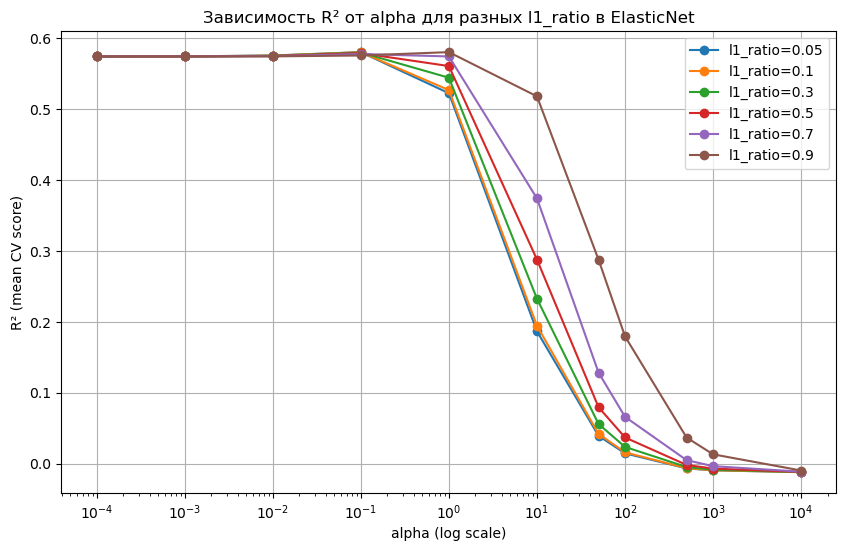

In [125]:
# Результаты и визуализация
cv = grid_search.cv_results_

df = pd.DataFrame({
    "alpha": [params["alpha"] for params in cv["params"]],
    "l1_ratio": [params["l1_ratio"] for params in cv["params"]],
    "mean_test_score": cv["mean_test_score"],
})

# Рисуем линии для каждого l1_ratio
plt.figure(figsize=(10, 6))

for l1 in sorted(df["l1_ratio"].unique()):
    subset = df[df["l1_ratio"] == l1].sort_values("alpha")
    plt.plot(subset["alpha"], subset["mean_test_score"], marker="o", label=f"l1_ratio={l1}")

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R² (mean CV score)")
plt.title("Зависимость R² от alpha для разных l1_ratio в ElasticNet")
plt.legend()
plt.grid(True)
plt.show()

вывод - ElasticNet, в отличие от lasso, плохо воспринимает большие значения alpha (после 10 качество рухнуло). 

Возможно стоит поподробнее перебрать параметры alpha в диапазоне от 0.1 до 10:

In [126]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()

param_grid = {
    'alpha': [0.1, 0.13, 0.17, 0.22, 0.29, 0.38, 0.50, 0.67, 0.89,
          1.2, 1.6, 2.1, 2.8, 3.7, 4.9, 6.5, 8.6, 11],
    'l1_ratio': [0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search_elastic = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_search_elastic.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.13, 0.17, 0.22, 0.29, 0.38, 0.5, 0.67,
                                   0.89, 1.2, 1.6, 2.1, 2.8, 3.7, 4.9, 6.5, 8.6,
                                   11],
                         'l1_ratio': [0.05, 0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

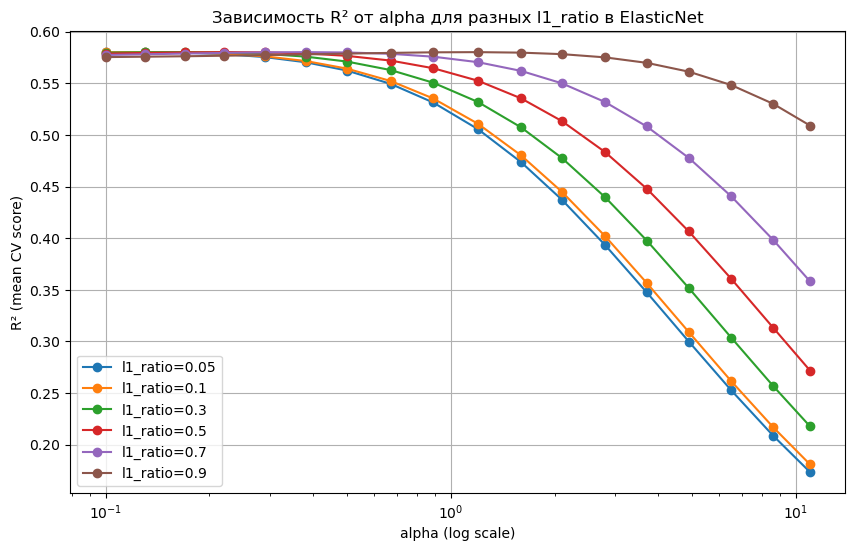

In [127]:
# Результаты и визуализация
cv = grid_search_elastic.cv_results_

df = pd.DataFrame({
    "alpha": [params["alpha"] for params in cv["params"]],
    "l1_ratio": [params["l1_ratio"] for params in cv["params"]],
    "mean_test_score": cv["mean_test_score"],
})

# Рисуем линии для каждого l1_ratio
plt.figure(figsize=(10, 6))

for l1 in sorted(df["l1_ratio"].unique()):
    subset = df[df["l1_ratio"] == l1].sort_values("alpha")
    plt.plot(subset["alpha"], subset["mean_test_score"], marker="o", label=f"l1_ratio={l1}")

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R² (mean CV score)")
plt.title("Зависимость R² от alpha для разных l1_ratio в ElasticNet")
plt.legend()
plt.grid(True)
plt.show()

In [128]:
elastic_best = grid_search_elastic.best_estimator_
elastic_best.feature_names_ = X_train_scaled.columns.tolist()

Вывод: перебрав подробнее значения альфа в диапазоне между 0.1 и 10 я не нашел ничего интересного

In [129]:
# вывод лучших значений 
print("Лучший alpha:", grid_search.best_params_['alpha'])
print("Лучший l1_ratio:", grid_search.best_params_['l1_ratio'])
print("Лучшее R²:", grid_search.best_score_)

print("Коэффициенты модели:")
print(grid_search.best_estimator_.coef_)

Лучший alpha: 1
Лучший l1_ratio: 0.9
Лучшее R²: 0.5801094229445762
Коэффициенты модели:
[153620.82870595 -51800.1522707   -1831.73946799  48644.15544404
 267160.46307348 -33379.40574943 -43539.4110357   32983.84003361]


### **Задание 18 (0.35 балла)**

И так, вы обучили все варианты регуляризаций, доступные в sklearn, но не все, что мы обсудили на занятии! И следующее задание о забытой - $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [136]:
# your code here
# ...реализуйте модель...
# насколько я понял эта регуляризация просто обучает на всех возможных комбинациях признаков.
# У нас 8 признаков, то есть будет 2^8 моделей

def mask_generator(k):
    """
    Генерирует все 2^k маски длины k
    Каждый элемент маски = 0 или 1
    """
    n_masks = 2 ** k
    for i in range(1, n_masks): # 0 пропускаем, тк обучать на всех нулях нет смысла
        # превращаем число i в бинарную строку длины k, потом в список 0/1
        mask = [(i >> j) & 1 for j in reversed(range(k))]
        yield mask

# пример работы
for mask in mask_generator(3):
    print(mask)

[0, 0, 1]
[0, 1, 0]
[0, 1, 1]
[1, 0, 0]
[1, 0, 1]
[1, 1, 0]
[1, 1, 1]


In [140]:
# хранить результаты будем в виде словаря {маска : (R^2 метрика на трейне, R^2 метрика на тесте)}

results = {}

X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()


for mask in mask_generator(X_train_np.shape[1]):
    # Выбираем только включённые признаки
    mask_array = np.array(mask, dtype=bool)
    X_train_sub = X_train_np[:, mask_array]
    X_test_sub = X_test_np[:, mask_array]
    
    # Обучаем линейную регрессию (дефолтную вроде бы нормально будет)
    model = LinearRegression()
    model.fit(X_train_sub, y_train)
    
    # Считаем R² на train и test
    r2_train = r2_score(y_train, model.predict(X_train_sub))
    r2_test = r2_score(y_test, model.predict(X_test_sub))
    
    # Сохраняем в словарь
    results[tuple(mask)] = (r2_train, r2_test)


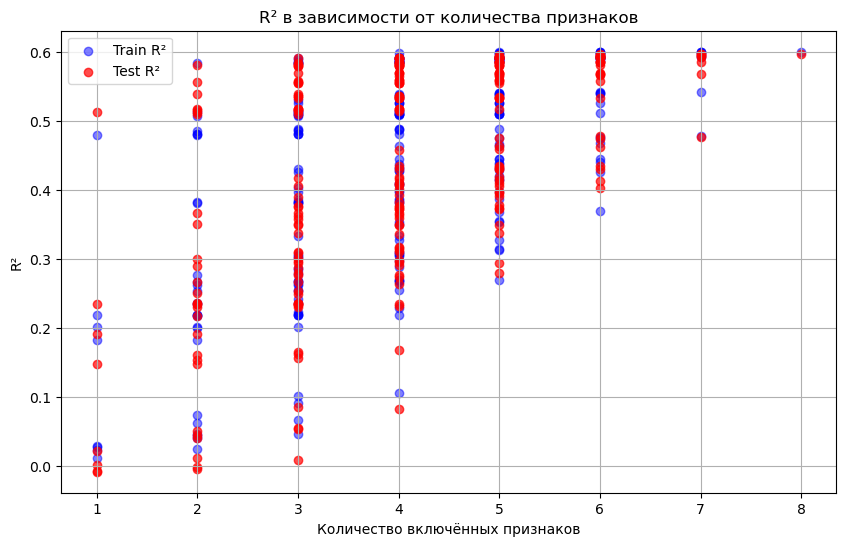

In [141]:
# небольшая визуализация - качество по числу включенных признаков

num_features = [sum(mask) for mask in results.keys()]
r2_test = [v[1] for v in results.values()]
r2_train = [v[0] for v in results.values()]

plt.figure(figsize=(10,6))
plt.scatter(num_features, r2_train, color='blue', alpha=0.5, label='Train R²')
plt.scatter(num_features, r2_test, color='red', alpha=0.7, label='Test R²')
plt.xlabel('Количество включённых признаков')
plt.ylabel('R²')
plt.title('R² в зависимости от количества признаков')
plt.legend()
plt.grid(True)
plt.show()

Выводы
- На двух признаках можно получить качество 0.55 (примерно), что совсем немного ниже самого высокого качества. 
- ВСего на одном признаке можно получить качество чуть меньше чем 0.5
- Это говорит о том, что у модели есть буквально 2-3 очень важных признака, которые дают почти все качество

In [142]:

top_masks = sorted(results.items(), key=lambda x: x[1][1], reverse=True)[:10]
for mask, (r2_train, r2_test) in top_masks:
    print(mask, r2_train, r2_test)
# лучшее качество - на какой маске и какое качество. Занятно что все эти модели все еще немого переобучены

(1, 1, 1, 1, 1, 1, 1, 0) 0.5999780182117028 0.5962191372448704
(1, 1, 0, 1, 1, 1, 1, 0) 0.5998870277036823 0.5962050251363284
(1, 1, 1, 1, 1, 1, 1, 1) 0.6000904696530602 0.5961443829496358
(1, 1, 0, 1, 1, 1, 1, 1) 0.5999819216482607 0.5961425685024777
(1, 1, 1, 0, 1, 1, 1, 0) 0.599721700887776 0.5956192823081188
(1, 1, 1, 0, 1, 1, 1, 1) 0.5998739827925161 0.5955703945590858
(1, 1, 0, 0, 1, 1, 1, 0) 0.5994337705693447 0.5953368617866573
(1, 1, 0, 0, 1, 1, 1, 1) 0.5995669234531231 0.5952905619717499
(1, 1, 1, 1, 1, 1, 0, 1) 0.5924101533486452 0.5942095533538905
(1, 1, 0, 1, 1, 1, 0, 1) 0.5914242860347447 0.5939315469332783


# **Часть 3 (0.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи. 

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.1 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [143]:
# Для train
df_train['first_word'] = df_train['name'].str.split().str[0]

# Для test
df_test['first_word'] = df_test['name'].str.split().str[0]

# Проверка
print(df_train[['first_word']].nunique())
print(df_test[['first_word']].nunique())

first_word    30
dtype: int64
first_word    25
dtype: int64


In [144]:
#assert X_train_cat.shape == (5840, 11)

In [145]:
#X_train_cat.describe(include='object')

### **Задание 20 (0.1 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [146]:
df_train.select_dtypes(include=["object"])

,name,fuel,seller_type,transmission,owner,first_word
0,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Diesel,Individual,Manual,Second Owner,Skoda
2,Hyundai i20 Sportz Diesel,Diesel,Individual,Manual,First Owner,Hyundai
3,Maruti Swift VXI BSIII,Petrol,Individual,Manual,First Owner,Maruti
4,Hyundai Xcent 1.2 VTVT E Plus,Petrol,Individual,Manual,First Owner,Hyundai
...,...,...,...,...,...,...
5835,Hyundai Santro Xing GLS,Petrol,Individual,Manual,First Owner,Hyundai
5836,Maruti Wagon R VXI BS IV with ABS,Petrol,Individual,Manual,Second Owner,Maruti
5837,Hyundai i20 Magna,Petrol,Individual,Manual,First Owner,Hyundai
5838,Hyundai Verna CRDi SX,Diesel,Individual,Manual,Fourth & Above Owner,Hyundai


In [147]:
from sklearn.preprocessing import OneHotEncoder # или можно использовать get_dummies из библиотеки pandas

# your code here
cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(cat_cols)
cat_cols.remove('name')

temp_X_train = df_train[cat_cols]
temp_X_test  = df_test[cat_cols]

#OHE на всех категориальных признаках
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
X_train_ohe = ohe.fit_transform(temp_X_train)
X_test_ohe = ohe.transform(temp_X_test)

ohe_cols = ohe.get_feature_names_out(cat_cols)
X_train_ohe.shape

['name', 'fuel', 'seller_type', 'transmission', 'owner', 'first_word']


(5840, 39)

In [148]:
# Немного более корректная обработка для сохранения названий признаков
ohe_cols = ohe.get_feature_names_out(cat_cols)

# Превращаем в DataFrame и присваиваем имена колонок
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=df_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=df_test.index)

X_train_ohe.shape


(5840, 39)

In [149]:
X_train_ohe.columns

Index(['fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner', 'first_word_Audi',
       'first_word_BMW', 'first_word_Chevrolet', 'first_word_Daewoo',
       'first_word_Datsun', 'first_word_Fiat', 'first_word_Force',
       'first_word_Ford', 'first_word_Honda', 'first_word_Hyundai',
       'first_word_Isuzu', 'first_word_Jaguar', 'first_word_Jeep',
       'first_word_Kia', 'first_word_Land', 'first_word_Lexus',
       'first_word_MG', 'first_word_Mahindra', 'first_word_Maruti',
       'first_word_Mercedes-Benz', 'first_word_Mitsubishi',
       'first_word_Nissan', 'first_word_Peugeot', 'first_word_Renault',
       'first_word_Skoda', 'first_word_Tata', 'first_word_Toyota',
       'first_word_Volkswagen', 'first_word_Volvo'],
      dtype='object')

### **Задание 21 (0.2 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

`Your answer here`

- Обучить OHE надо только на трейне, чтобы не подсматривать в категории теста. Надо корректно обрабатывать неизвестные значения (могут появиться в тесте)
- 1 столбец однозначно выражается из остальных. Он будет иметь единичку там, где в остальных столбцах нолики, или нолик там, где есть хоть одна единичка. Однако удаление не обязательно, линейные модели хорошо работают и без удаления, если есть регуляризация.
- Сумма каждого объекта в этих признаках равна одному, и удалив k столбиков это свойство ломается. 

### **Задание 22 (0.1 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

   param_alpha  mean_train_score  mean_test_score
0        0.001          0.766818         0.696040
1         0.01          0.766817         0.696104
2          0.1          0.766740         0.696611
3            1          0.763624         0.699550
4           10          0.735316         0.693830
5          100          0.679528         0.657745
6          500          0.645231         0.633647
7         1000          0.625012         0.619814
8        10000          0.436340         0.457263
9        50000          0.186468         0.194953
10      100000          0.108761         0.109464


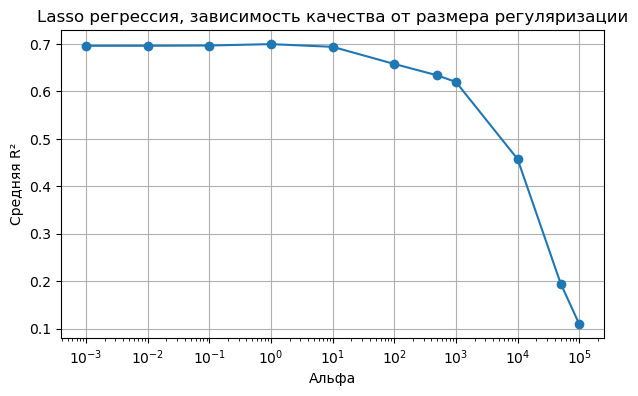

Лучший альфа: 1
Лучшее R²: 0.6995495433584159


In [150]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# your code here

# новый полный датасетик
X_train_full = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_test_full  = pd.concat([X_test_scaled, X_test_ohe], axis=1)

# модель
ringe = Ridge(max_iter=20000)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 10000, 50000, 100000]
}

grid_search_ringe = GridSearchCV(
    estimator=ringe,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    return_train_score=True
)

grid_search_ringe.fit(X_train_full, y_train)


results = pd.DataFrame(grid_search_ringe.cv_results_)
table = results[['param_alpha', 'mean_train_score', 'mean_test_score']]
print(table)

# график запвисимости метрики от размера альфа
plt.figure(figsize=(7,4))
plt.plot(results['param_alpha'], results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('Альфа')
plt.ylabel('Средняя R²')
plt.title('Lasso регрессия, зависимость качества от размера регуляризации')
plt.grid(True)
plt.show()

# информация о лучшем 
print("Лучший альфа:", grid_search_ringe.best_params_['alpha'])
print("Лучшее R²:", grid_search_ringe.best_score_)
# print("Коэффициенты:", grid_search_ringe.best_estimator_.coef_)

Вывод - качество прогноза улучшить удалось, с примерно 0.6 до 0.69 по метрике $R^2$

In [151]:
# для корректного сохрнанения в pickle и для app.py
best_ringe = grid_search_ringe.best_estimator_
best_ringe.feature_names_ = X_train_full.columns.tolist()

# **Часть 4 - бонусная (1 балл) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый пункт по 0.4 балла, но не больше 1-х балла в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*
    * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
    * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*
    * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
    * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*
    * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
    * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
    * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
    * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

План:
- Исправить таргет чтобы был нормальнее
- Подумать какие признаки можно добавить и добавить их
- Разобраться с выбросами 
- Обучить новую модель на всем этом многообразии безобразия

Что сделал
- Логарифмировал таргет
- Добавил признаки (штуки 4)
- Выбросы решил не чистить (психическое здоровье важнее)
- Модель обучил, качество подросло
- profit

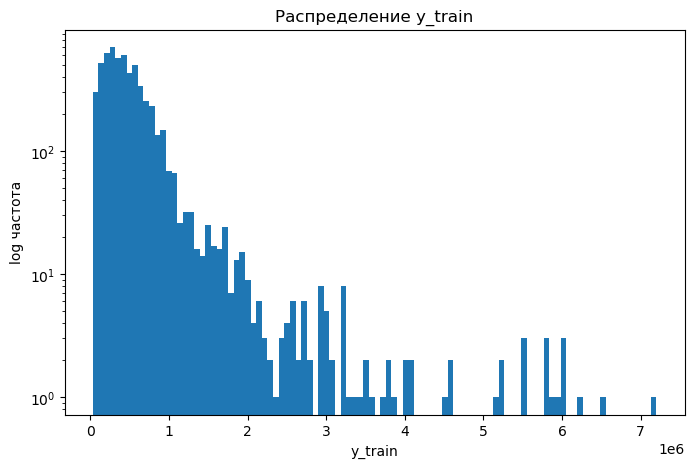

In [152]:
# your code here
plt.figure(figsize=(8, 5))
plt.hist(y_train [y_train < 10000000], bins=100)
plt.xlabel("y_train")
plt.yscale("log")
plt.ylabel("log частота")
plt.title("Распределение y_train")
plt.show()


In [153]:
df_test.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'max_torque_rpm', 'torque', 'first_word'],
      dtype='object')

In [154]:
# признаки 

# Превратить год выпуска в возраст машины, и добавить к этому возрасту нелинейность (цена должна падать медленне для более старых машин)
current_year = 2021
df_train['car_age'] = current_year - df_train['year']
df_train['car_age_nl'] = np.log1p(df_train['car_age']) # логарифм возраста - замедляет старение

# Пересчитать мощность на литр (max_power/ engine). 
df_train['power_per_liter'] = df_train['max_power'] / df_train['engine'] # единица на всякий случай

# средний пробег в год (например, если машина использовалась в такси -> очень много ездила)
df_train['km_per_year'] = df_train['km_driven'] / df_train['car_age']

# сегмент автомобиля (по имени) (позволяет учитывать влияние группы брендов, а не отдельного бренда в 1hot). 

# Словарь премиальности
brand_premium_map = {
    'Maruti': 0, 'Hyundai': 0, 'Tata': 0, 'Mahindra': 0, 'Datsun': 0,
    'Ford': 1, 'Skoda': 1, 'Honda': 1, 'Chevrolet': 1, 'Renault': 1,
    'Toyota': 1, 'Mitsubishi': 1, 'Fiat': 1, 'Kia': 1,
    'BMW': 2, 'Mercedes-Benz': 2, 'Audi': 2, 'Lexus': 2, 'Jaguar': 2,
    'Land': 2, 'Volvo': 2, 'MG': 1, 'Daewoo': 0, 'Peugeot': 1,
    'Jeep': 1, 'Force': 0, 'Ambassador': 0, 'Isuzu': 1, 'Volkswagen':2, 'Nissan':1
}

# Создаем новый столбец с премиальностью
df_train['brand_premium'] = df_train['first_word'].map(brand_premium_map)

## то же для теста 

# возраст машины
df_test['car_age'] = current_year - df_test['year']
df_test['car_age_nl'] = np.log1p(df_test['car_age'])  # логарифм возраста

# мощность на литр
df_test['power_per_liter'] = df_test['max_power'] / df_test['engine']

# средний пробег в год
df_test['km_per_year'] = df_test['km_driven'] / df_test['car_age']

# премиальный сегмент
df_test['brand_premium'] = df_test['first_word'].map(brand_premium_map)

# проверка, есть ли марки без премиальности
missing_brands = df_test[df_test['brand_premium'].isna()]['first_word'].unique()
print("Бренды без премиального класса в тесте:", missing_brands) # проблема 1h энкодера

Бренды без премиального класса в тесте: ['Opel' 'Ashok']


In [155]:
# Заполнение пропусков (немного костыльное)
df_train['power_per_liter'] = df_train['power_per_liter'].fillna(df_train['power_per_liter'].mean())
df_test['power_per_liter']  = df_test['power_per_liter'].fillna(df_train['power_per_liter'].mean())

df_train['brand_premium'] = df_train['brand_premium'].fillna(1)
df_test['brand_premium']  = df_test['brand_premium'].fillna(1)

In [171]:
# Финал - добавить признаки в учебный датасет

num_features = ['car_age', 'car_age_nl', 'power_per_liter', 'km_per_year', 'brand_premium']
cat_features = ['brand_premium', 'first_word']

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
ohe.fit(df_train[cat_features])
X_train_ohe_array = ohe.transform(df_train[cat_features])
X_test_ohe_array  = ohe.transform(df_test[cat_features])
ohe_cols = ohe.get_feature_names_out(cat_features)
X_train_ohe = pd.DataFrame(X_train_ohe_array, columns=ohe_cols, index=df_train.index)
X_test_ohe  = pd.DataFrame(X_test_ohe_array,  columns=ohe_cols, index=df_test.index)

X_train_num = df_train[num_features]
X_test_num  = df_test[num_features]

# объединяем все - существующие + числовые + OHE
X_train_full3 = pd.concat([X_train_full, X_train_num, X_train_ohe], axis=1)
X_test_full3  = pd.concat([X_test_full,  X_test_num,  X_test_ohe],  axis=1)


print("Форма X_train_full3:", X_train_full3.shape)
print("Форма X_test_full3:",  X_test_full3.shape)
 


Форма X_train_full3: (5840, 83)
Форма X_test_full3: (1000, 83)


  param_regressor__alpha  mean_train_score  mean_test_score
0                  0.001          0.913281         0.883212
1                   0.01          0.911735         0.880638
2                    0.1          0.901356         0.865514
3                      1          0.889274         0.850292
4                     10          0.872998         0.844980
5                    100          0.857006         0.845086
6                    500          0.835060         0.833274
7                   1000          0.809575         0.812934
8                  10000          0.501926         0.533558


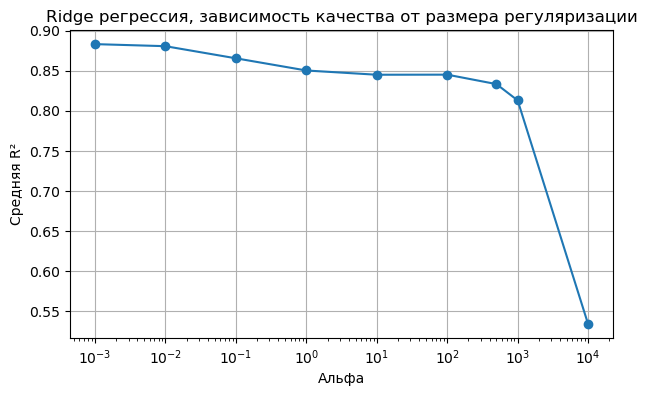

Лучший альфа: 0.001
Лучшее R²: 0.8832121217347092


In [172]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

super_ringe = Ridge(max_iter=20000)
# какая-то умная регрессия, которая автоматически логарифмирует y
model = TransformedTargetRegressor(
    regressor=super_ringe,
    func=np.log1p,
    inverse_func=np.expm1
)

param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 10000]
}

grid_search_full = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,
    scoring='r2',
    return_train_score=True
)

grid_search_full.fit(X_train_full3, y_train)   # тут именно оригинальный y, логарифмирование внутри модели


# визуализация результатов
results = pd.DataFrame(grid_search_full.cv_results_)

# вот тут вот я не совсем понимаю почему такие названия, но оно работает
table = results[['param_regressor__alpha', 'mean_train_score', 'mean_test_score']]
print(table)

# график зависимости метрики от размера альфа
plt.figure(figsize=(7, 4))
plt.plot(results['param_regressor__alpha'], results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('Альфа')
plt.ylabel('Средняя R²')
plt.title('Ridge регрессия, зависимость качества от размера регуляризации')
plt.grid(True)
plt.show()

# информация о лучшем
print("Лучший альфа:", grid_search_full.best_params_['regressor__alpha'])
print("Лучшее R²:", grid_search_full.best_score_)
# print("Коэффициенты:", grid_search_full.best_estimator_.regressor_.coef_)

Вывод: либо из-за новых ли признаков, либо из-за логарифмирования таргета, получилось повысить качество (возможно виновато и то и то)


# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 23 (0.25 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса

In [174]:
def business_metrics(y_true, y_pred):
    mask = np.abs(y_pred - y_true) / y_true <= 0.10 
    return np.mean(mask)



# scaled_model - масштабировал признаки
X_test = X_test_scaled
y_pred_scaled = scaled_model.predict(X_test)
print("Scaled model → business metric:", business_metrics(y_test, y_pred_scaled))


# lasso_model - лассо регуляризация (не оптимальный альфа)
X_test = X_test_scaled
y_pred_lasso = lasso_model.predict(X_test)
print("Lasso → business metric:", business_metrics(y_test, y_pred_lasso))


# grid_search_lasso (same, оптимальный альфа)
X_test = X_test_scaled
best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso_best = best_lasso.predict(X_test)
print("GridSearch Lasso → business metric:", business_metrics(y_test, y_pred_lasso_best))


# grid_search_elastic (эластик)
X_test = X_test_scaled
best_elastic = grid_search_elastic.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)
print("ElasticNet → business metric:", business_metrics(y_test, y_pred_elastic))


# grid_search_ringe (ридж с категориальными признаками)
X_test = X_test_full
best_ringe = grid_search_ringe.best_estimator_
y_pred_ridge = best_ringe.predict(X_test)
print("Ridge (categorical) → business metric:", business_metrics(y_test, y_pred_ridge))


# grid_search_full (ридж с сейф-мейд признаками, лог таргет)
X_test = X_test_full3
best_full = grid_search_full.best_estimator_
y_pred_full = best_full.predict(X_test)
print("Full ridge (log-target) → business metric:", business_metrics(y_test, y_pred_full))

Scaled model → business metric: 0.241
Lasso → business metric: 0.241
GridSearch Lasso → business metric: 0.245
ElasticNet → business metric: 0.252
Ridge (categorical) → business metric: 0.283
Full ridge (log-target) → business metric: 0.358


### **Задание 24 (0.25 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса



In [175]:
# идея та же - есть окно +-10 процентов, в которую нужно попасть модели. Но теперь окно сверху становится в k раз больше, что 10 процентов
def your_business_metrics(y_true, y_pred, k=1):
    """
    Оценка точности с окном +-10%, но перепрогноз учитывается как k раз шире
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    lower_bound = y_true * 0.9
    upper_bound = y_true * (1 + 0.1 * k)  # окно сверху увеличено в k раз

    mask = (y_pred >= lower_bound) & (y_pred <= upper_bound)
    return np.mean(mask)




k = 2
# scaled_model - масштабировал признаки
X_test = X_test_scaled
y_pred_scaled = scaled_model.predict(X_test)
print("Scaled model → business metric:", your_business_metrics(y_test, y_pred_scaled, k))


# lasso_model - лассо регуляризация (не оптимальный альфа)
X_test = X_test_scaled
y_pred_lasso = lasso_model.predict(X_test)
print("Lasso → business metric:", your_business_metrics(y_test, y_pred_lasso, k))


# grid_search_lasso (same, оптимальный альфа)
X_test = X_test_scaled
best_lasso = grid_search_lasso.best_estimator_
y_pred_lasso_best = best_lasso.predict(X_test)
print("GridSearch Lasso → business metric:", your_business_metrics(y_test, y_pred_lasso_best, k))


# grid_search_elastic (эластик)
X_test = X_test_scaled
best_elastic = grid_search_elastic.best_estimator_
y_pred_elastic = best_elastic.predict(X_test)
print("ElasticNet → business metric:", your_business_metrics(y_test, y_pred_elastic,k))


# grid_search_ringe (ридж с категориальными признаками)
X_test = X_test_full
best_ringe = grid_search_ringe.best_estimator_
y_pred_ridge = best_ringe.predict(X_test)
print("Ridge (categorical) → business metric:", your_business_metrics(y_test, y_pred_ridge,k))


# grid_search_full (ридж с сейф-мейд признаками, лог таргет)
X_test = X_test_full3
best_full = grid_search_full.best_estimator_
y_pred_full = best_full.predict(X_test)
print("Full ridge (log-target) → business metric:", your_business_metrics(y_test, y_pred_full,k))

Scaled model → business metric: 0.334
Lasso → business metric: 0.334
GridSearch Lasso → business metric: 0.346
ElasticNet → business metric: 0.332
Ridge (categorical) → business metric: 0.381
Full ridge (log-target) → business metric: 0.468


# **Часть 6 (1 балл) | Оформление результатов**

### **Задание 25**

**Результаты вашей работы** необходимо разместить в своем Гитхабе. Далее в этот же репозиторий вы прикрепите вторую часть. Под результатами первой части понимаем следующее:
* ``.ipynb``-ноутбук со всеми проведёнными вами экспериментами (output'ы ячеек, разумеется, сохранить)
* ``.pickle``-файл с сохранёнными весами модели, коэффициентами скейлинга и прочими числовыми значениями, которые могут понадобиться для инференса
* ``.md``-файл с выводами про проделанной вами работе:
    * что было сделано
    * с какими результатами
    * что дало наибольший буст в качестве
    * что сделать не вышло и почему (это нормально, даже хорошо😀)

**За что могут быть сняты баллы в этом пункте:**
* за отсутствие ``.pickle``-файла с весами использованной модели
* за недостаточную аналитику в ``.md``-файле
* за оформление и логику кода (в определённом смысле это тоже элемент оформления решения)

In [167]:
import os
import pickle

model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

print(f"📁 Директория '{model_dir}' создана или уже существует")
def save_model(path, model):
    os.makedirs(path, exist_ok=True)
    print(f"Сохраняем модель через Pickle в папку: {path}")
    print("-" * 60)

    # 📂 Путь к файлу модели
    model_path = os.path.join(path, 'cars_regression.pkl')
    print(f"📝 model_path: {model_path}")

    # ВАЖНО: открываем файл в бинарном режиме ('wb' = write binary)
    with open(model_path, 'wb') as f:
        # сериализуем модель
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"   Размер файла: {os.path.getsize(model_path) / 1024:.2f} KB 🗃️")
    print("-" * 60)
    print("🎉 Модель успешно сохранена через Pickle! 🥳✨")

    # 🏷️ Также сохраним список признаков для удобства
    feature_names_path = os.path.join(path, 'cars_regression_features.pkl')
    print(f"📝 feature_names_path: {feature_names_path}")

    with open(feature_names_path, 'wb') as f:
        pickle.dump(model.feature_names_, f, protocol=4)

    print(f"✅ Список признаков из переменной 'model.feature_names_' сохранен в файл: {feature_names_path} 📋")
    print("-" * 60)
    print("🎉 Сохранение признаков успешно выполнено! 🎊🔥")
# сохранение моделей
models = {
    "base_model": base_model,
    "scaled_model": scaled_model,
    "lasso_model": lasso_model,
    "lasso_best": lasso_best,
    "elastic_best": elastic_best,
    "best_ringe": best_ringe,
}

for name, model in models.items():
    save_model(os.path.join(model_dir, name), model)

📁 Директория 'models' создана или уже существует
Сохраняем модель через Pickle в папку: models/base_model
------------------------------------------------------------
📝 model_path: models/base_model/cars_regression.pkl
   Размер файла: 0.75 KB 🗃️
------------------------------------------------------------
🎉 Модель успешно сохранена через Pickle! 🥳✨
📝 feature_names_path: models/base_model/cars_regression_features.pkl
✅ Список признаков из переменной 'model.feature_names_' сохранен в файл: models/base_model/cars_regression_features.pkl 📋
------------------------------------------------------------
🎉 Сохранение признаков успешно выполнено! 🎊🔥
Сохраняем модель через Pickle в папку: models/scaled_model
------------------------------------------------------------
📝 model_path: models/scaled_model/cars_regression.pkl
   Размер файла: 0.75 KB 🗃️
------------------------------------------------------------
🎉 Модель успешно сохранена через Pickle! 🥳✨
📝 feature_names_path: models/scaled_model/ca